# Задача 1

Задание:
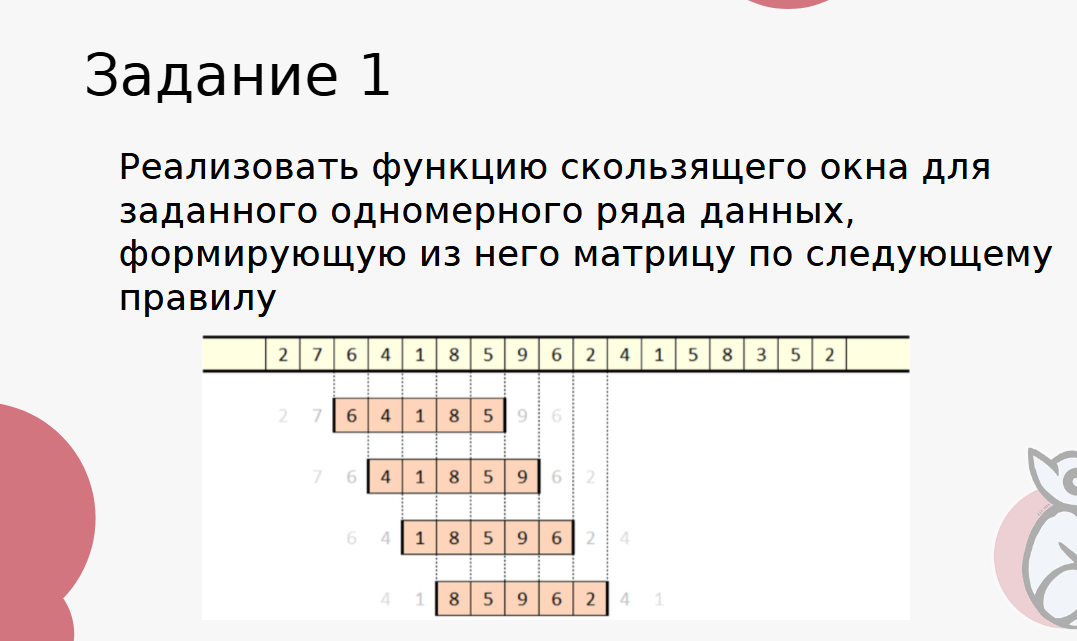

Реализованная функция(x - исходный массив, w - размер окна, step - размер шага для каждого окна):

In [1]:
def sliding_window(x, w, step):
  out = []
  i = 0
  while i < len(x) - w + 1:
    out.append(x[i:i+w])
    i += step
  return out


Проверка:

In [2]:
import numpy as np
window = 3
step_s = 1
x1 = np.array([8, 1, 4, 5, -2, 5, 9, 0])
A1 = np.array([[8, 1, 4],
               [1, 4, 5],
               [4, 5, -2],
               [5, -2, 5],
               [-2, 5, 9],
               [5, 9, 0]])

print(np.array_equal(sliding_window(x1, w=window, step=step_s),A1))

window = 2
step_s = 4
x2 = np.array([8, 3, 4, 1, -6, 5, 9, 2, 10, 11, -14, 0])
A2 = np.array([[8, 3],
               [-6, 5],
               [10, 11]])

print(np.array_equal(sliding_window(x2, w=window, step=step_s),A2))

True
True


# Задача 2

Задание:
Взять данные по ссылке и ответить на вопросы:
1.         Сколько мужчин и женщин (признак sex) представлено в этом наборе данных?
2.         Каков средний возраст (признак age) женщин?
3.         Какова доля граждан Германии (признак native-country)?
4.         Постройте гистограмму распределения (bar plot) образования людей (признак education).
5.         Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает менее 50K в год?
6.         Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education – Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)
7.         Выведите статистику возраста для каждой расы (признак race) и каждого пола. Используйте groupby и describe. Каков максимальный возраст мужчин расы Amer-Indian-Eskimo?
8.         Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми
9.         Какое максимальное число часов человек работает в неделю (признак hours-per-week)? Сколько людей работают такое количество часов и каков среди них процент зарабатывающих много?
10.      Посчитайте среднее время работы (hours-per-week) зарабатывающих мало и много (salary) для каждой страны (native-country)


Решение:

In [ ]:
#Импортируем библиотеки

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
#Загружаем датасет
data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data", names = ["age", "workclass", "fnlwgt", "education",
                    "education-num", "marital-status", "occupation", "relationship",
                    "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "salary"], sep=", ")

data.head()

<ipython-input-6-95e2bf200640>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data", names = ["age", "workclass", "fnlwgt", "education",


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


sex
Female    10771
Male      21790
dtype: int64


<Axes: >

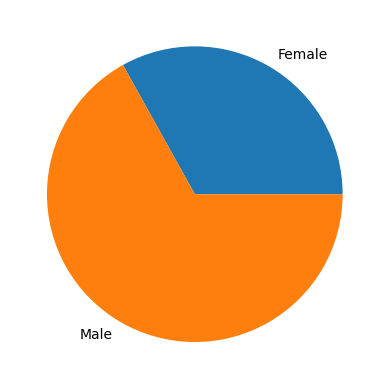

In [ ]:
#1 Сколько мужчин и женщин (признак sex) представлено в этом наборе данных?
grouped = data.groupby("sex").size()
print(grouped)
grouped.plot.pie()

In [ ]:
#2 Каков средний возраст (признак age) женщин?
print("Средний возраст: ", data.loc[data["sex"] == "Female", "age"].mean())

Средний возраст:  36.85823043357163


In [ ]:
#3 Какова доля граждан Германии (признак native-country)?
print("Доля немцев: ", len(data[data["native-country"] == "Germany"].index) / len(data.index))

Доля немцев:  0.004207487485028101


<Axes: xlabel='education', ylabel='Count'>

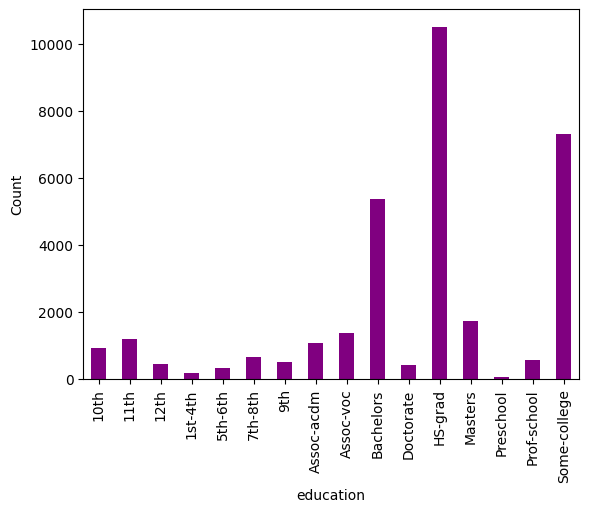

In [ ]:
#4 Постройте гистограмму распределения (bar plot) образования людей (признак education).
data.groupby("education").size().plot.bar(ylabel="Count", color="purple")

In [ ]:
#5 Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает менее 50K в год?
data.groupby("salary").agg({"age": ["mean", "std"]})

age           
             mean        std
salary                      
<=50K   36.783738  14.020088
>50K    44.249841  10.519028

<Axes: title={'center': 'Has cool education?'}>

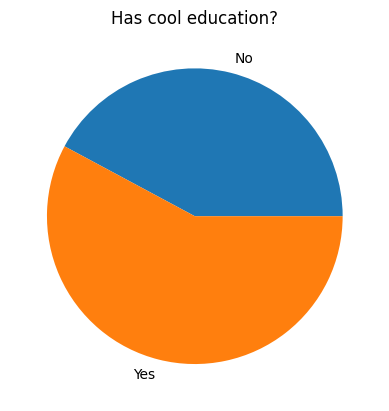

In [ ]:
#6 Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education – Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)
cool_ed = ["Bachelors", "Prof-school", "Assoc-acdm", "Assoc-voc", "Masters", "Doctorate"]
data_with_high_ed = data.assign(is_high_ed=np.where(data["education"].isin(cool_ed), "Yes", "No"))
data_with_high_ed.loc[data["salary"] == ">50K"].groupby("is_high_ed").size().plot.pie(title="Has cool education?")


In [ ]:
#7 Выведите статистику возраста для каждой расы (признак race) и каждого пола.
data.groupby(["race", "sex"]).age.describe()

count       mean        std   min   25%   50%  \
race               sex                                                       
Amer-Indian-Eskimo Female    119.0  37.117647  13.114991  17.0  27.0  36.0   
                   Male      192.0  37.208333  12.049563  17.0  28.0  35.0   
Asian-Pac-Islander Female    346.0  35.089595  12.300845  17.0  25.0  33.0   
                   Male      693.0  39.073593  12.883944  18.0  29.0  37.0   
Black              Female   1555.0  37.854019  12.637197  17.0  28.0  37.0   
                   Male     1569.0  37.682600  12.882612  17.0  27.0  36.0   
Other              Female    109.0  31.678899  11.631599  17.0  23.0  29.0   
                   Male      162.0  34.654321  11.355531  17.0  26.0  32.0   
White              Female   8642.0  36.811618  14.329093  17.0  25.0  35.0   
                   Male    19174.0  39.652498  13.436029  17.0  29.0  38.0   

                             75%   max  
race               sex                  
Amer-Indian-Eskimo Female  46.00  80.0  
                   Male    45.00  82.0  
Asian-Pac-Islander Female  43.75  75.0  
                   Male    46.00  90.0  
Black              Female  46.00  90.0  
                   Male    46.00  90.0  
Other              Female  39.00  74.0  
                   Male    42.00  77.0  
White              Female  46.00  90.0  
                   Male    49.00  90.0

In [ ]:
#8 Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)?

print("Женатых богачей: ", data.loc[(data["salary"] == ">50K") & (data["marital-status"].str.startswith("Married"))].shape[0])
print("Неженатых богачей: ", data.loc[(data["salary"] == ">50K") & (~data["marital-status"].str.startswith("Married"))].shape[0])

Женатых богачей:  6736
Неженатых богачей:  1105


99
Кол-во работяг:  85
Доля богатых работяг:  0.29411764705882354


Text(0, 0.5, 'hours per week')

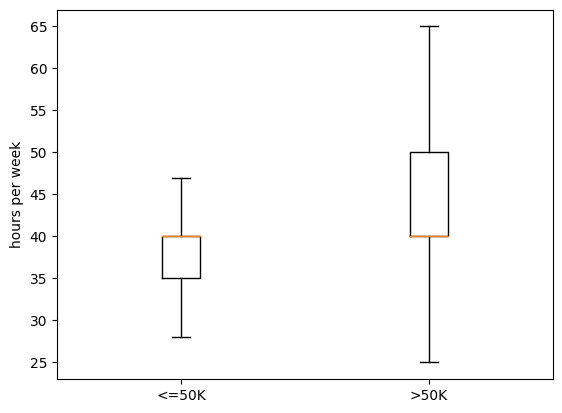

In [ ]:
#9 Какое максимальное число часов человек работает в неделю (признак hours-per-week)? Сколько людей работают такое количество часов и каков среди них процент зарабатывающих много?

max_hours = data["hours-per-week"].max()
print(max_hours)

workoholics = data.loc[data["hours-per-week"] == max_hours]
print("Кол-во работяг: ", len(workoholics.index))
print("Доля богатых работяг: ", len(workoholics[workoholics["salary"] == ">50K"].index) / len(workoholics.index))

#Диаграмма распределения времени работы для богатых и не богатых
low = data.loc[data["salary"] == "<=50K", "hours-per-week"]
high = data.loc[data["salary"] == ">50K", "hours-per-week"]
plt.boxplot([low, high], showfliers=False, labels=["<=50K", ">50K"])
plt.ylabel("Hours per week")

In [ ]:
#10 Посчитайте среднее время работы (hours-per-week) зарабатывающих мало и много (salary) для каждой страны (native-country)

data.groupby(["native-country", "salary"]).agg({"hours-per-week": "mean"})

hours-per-week
native-country salary                
?              <=50K        40.164760
               >50K         45.547945
Cambodia       <=50K        41.416667
               >50K         40.000000
Canada         <=50K        37.914634
...                               ...
United-States  >50K         45.505369
Vietnam        <=50K        37.193548
               >50K         39.200000
Yugoslavia     <=50K        41.600000
               >50K         49.500000

[82 rows x 1 columns]

from matplotlib import pyplot as plt
_df_0['hours-per-week'].plot(kind='hist', bins=20, title='hours-per-week')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['hours-per-week'].plot(kind='line', figsize=(8, 4), title='hours-per-week')
plt.gca().spines[['top', 'right']].set_visible(False)

# Задача 3

Задание:
Проанализировать свой датасет

In [ ]:
# Загрузка датасета про квартиры в Москве
flat_df = pd.read_csv("/content/drive/MyDrive/Data/Moscow_flats.csv")
flat_df.head(10)

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation
5,7150000.0,Secondary,Опалиха,6.0,Moscow region,1.0,38.4,18.0,8.0,8.0,18,European-style renovation
6,7400000.0,Secondary,Нахабино,11.0,Moscow region,1.0,33.0,16.0,8.0,7.0,7,European-style renovation
7,7500000.0,Secondary,Строгино,27.0,Moscow region,1.0,25.0,14.8,8.7,16.0,34,European-style renovation
8,7800000.0,Secondary,Красногорская,6.0,Moscow region,1.0,41.8,18.0,10.0,6.0,17,Cosmetic
9,7999999.0,Secondary,Тушинская,35.0,Moscow region,1.0,44.0,19.0,11.0,11.0,24,Designer


<Axes: >

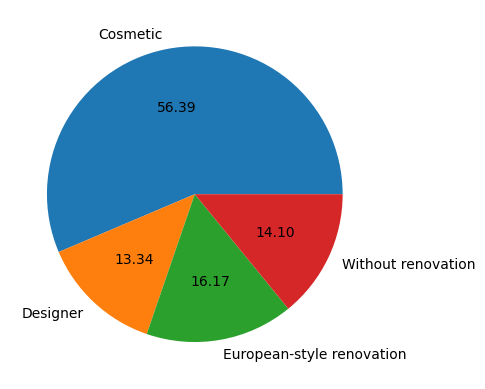

In [ ]:
#1 Распределение квартир по  ремонту
flat_df.groupby(["Renovation"]).size().plot.pie(autopct="%.2f")

In [ ]:
#2 15 станций метро, вокруг которых больше всего квартир

flat_df.groupby("Metro station").size().sort_values(ascending=False).head(15)

,0
Metro station,
Красногвардейская,2697
Депо,1646
Братиславская,1157
Котельники,981
Жулебино,731
Зябликово,716
Битца,360
Опалиха,305
Каширская,295


In [ ]:
#3 15 станций метро к которым в среднем меньше всего добираться
flat_df.groupby("Metro station").agg({"Minutes to metro": ["mean"]}).sort_values(("Minutes to metro", "mean")).head(15)

,Minutes to metro
,mean
Metro station,
Площадь Революции,1.600000
Октябрьская,1.800000
Каховская,2.000000
Тимирязевская,2.666667
Ясенево,3.000000
Карамышевская,3.272727
Деловой центр,3.333333
Тургеневская,3.650000


<Axes: xlabel='Apartment type', ylabel='Count'>

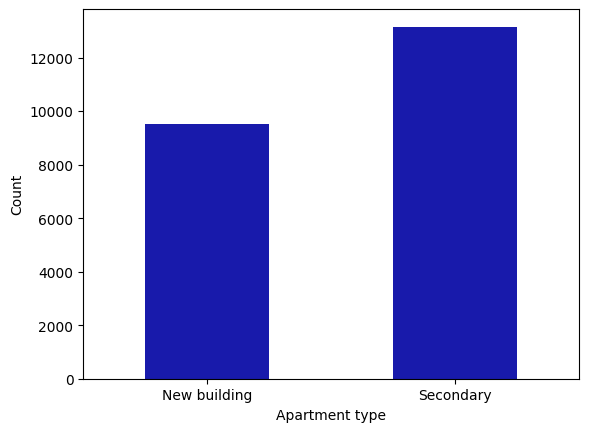

In [ ]:
#4 Распределение по типу квартиры
flat_df.groupby("Apartment type").size().plot.bar(ylabel="Count", color="#181aab", rot=0)

<Axes: xlabel='Price', ylabel='Region,Apartment type,Renovation'>

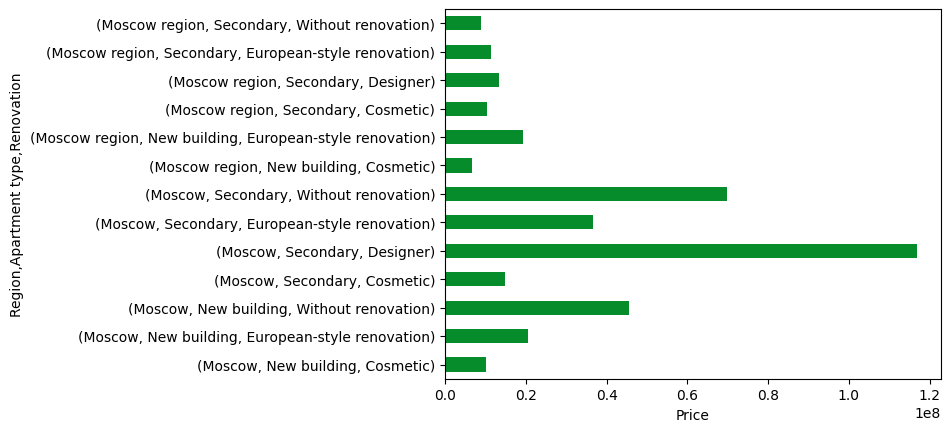

In [ ]:
#5 Средняя цена для различных комбинаций качесвенных признаков
flat_df.groupby(["Region", "Apartment type", "Renovation"]).Price.mean().round().plot.barh(xlabel="Price", color="#078c2b")

In [ ]:
#6 Средний уровень квартир в доме (по этажу)
(flat_df["Floor"] / flat_df["Number of floors"]).mean()

0.5880413913959963

<Axes: xlabel='Number of rooms', ylabel='Area'>

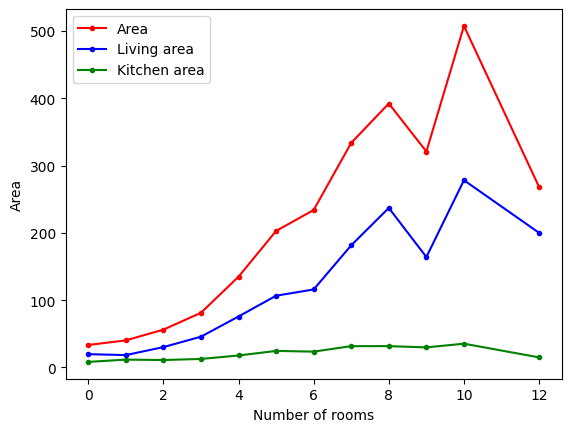

In [ ]:
#7 Зависимость разных площадей от количества комнат
flat_df.groupby("Number of rooms").agg({"Area": "mean", "Living area": "mean", "Kitchen area": "mean",}).plot.line(ylabel="Area", color=("red", "blue", "green"), style=".-")

<Axes: xlabel='Area', ylabel='Living area'>

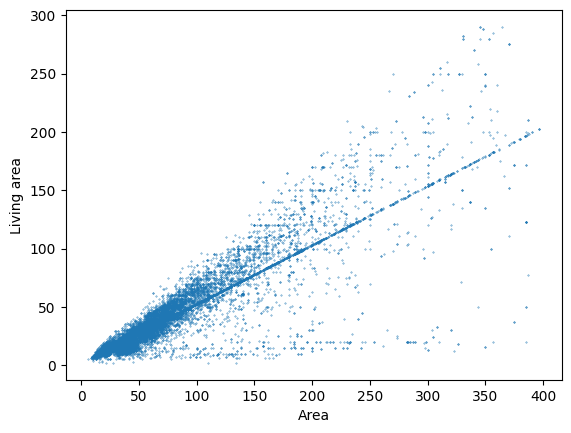

In [ ]:
#8 Соотнешение площади жилой и общей площади
flat_df[(flat_df["Area"] < 400) & (flat_df["Living area"] < 300)].plot.scatter(x="Area", y="Living area", s=0.1)

In [ ]:
#9 Корреляция различных числовых признаков с ценой квартиры
flat_df.loc[:, "Number of rooms":"Number of floors"].corrwith(flat_df["Price"])

,0
Number of rooms,0.490820
Area,0.794226
Living area,0.709296
Kitchen area,0.582940
Floor,0.019080
Number of floors,-0.022134


,0
Price,"Axes(0.125,0.11;0.775x0.77)"


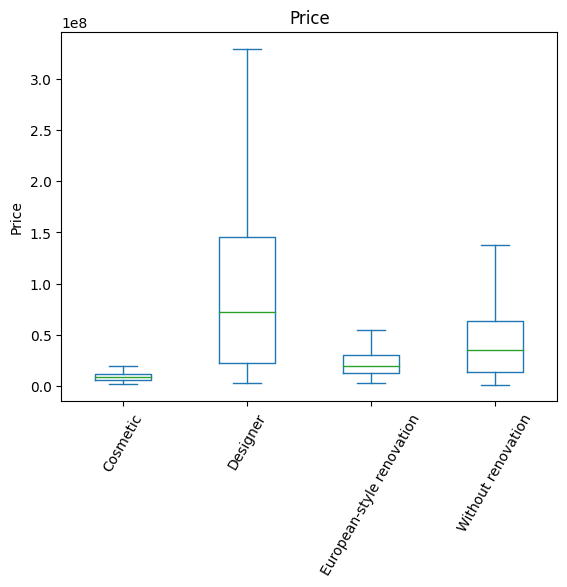

In [ ]:
#10 Распределение цены для каждого типа ремонта
flat_df.plot.box(column="Price", by="Renovation", showfliers=False, ylabel="Price", rot=60)